In [5]:
from parity_relu_experiment import ParityMLP, ParityMLP2, ParityMLP3, generate_parity_data, train_model, evaluate_model
import seaborn as sns
import matplotlib.pyplot as plt
import torch

Cannot run below on computer
TODO: import to other(turing)


In [ ]:

input_dim = 800
hidden_dim = 600

train_samples = 10000000
eval_samples = 12000

epochs = 100
batch_size = 256
lr = .001

device = "cpu"

train_x, train_y = generate_parity_data(train_samples, input_dim, device=device)
eval_x, eval_y = generate_parity_data(eval_samples, input_dim, device=device)

model = ParityMLP3(input_dim=input_dim, hidden_dim1=hidden_dim,hidden_dim2=hidden_dim)
train_loss = train_model(
    model,
    train_x,
    train_y,
    epochs=epochs,
    batch_size=batch_size,
    lr=lr,
    device=device
)
eval_mse, sign_accuracy = evaluate_model(model, eval_x, eval_y, device=device)
print(eval_mse, sign_accuracy )

In [5]:
sa_arr = []
eval_arr = []
loss_arr = []
model = ParityMLP3(input_dim=input_dim, hidden_dim1=hidden_dim, hidden_dim2 =hidden_dim)
for i in range(epochs):
        
    train_loss = train_model(
        model,
        train_x,
        train_y,
        epochs=1,
        batch_size=batch_size,
        lr=lr,
        device=device
    )
    eval_mse, sign_accuracy = evaluate_model(model, eval_x, eval_y, device=device)
    eval_arr.append(eval_mse)
    sa_arr.append(sign_accuracy)
    loss_arr.append(train_loss)
    
    

<Axes: >

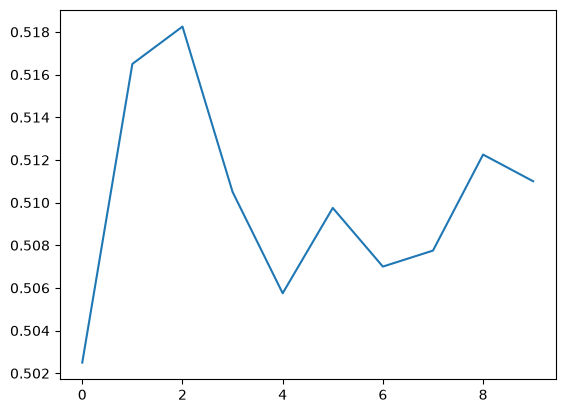

In [7]:
sns.lineplot(sa_arr)

Try with 10, 15 at some point

level 1 = hyperplanes. 

1785881.875 0.4951171875


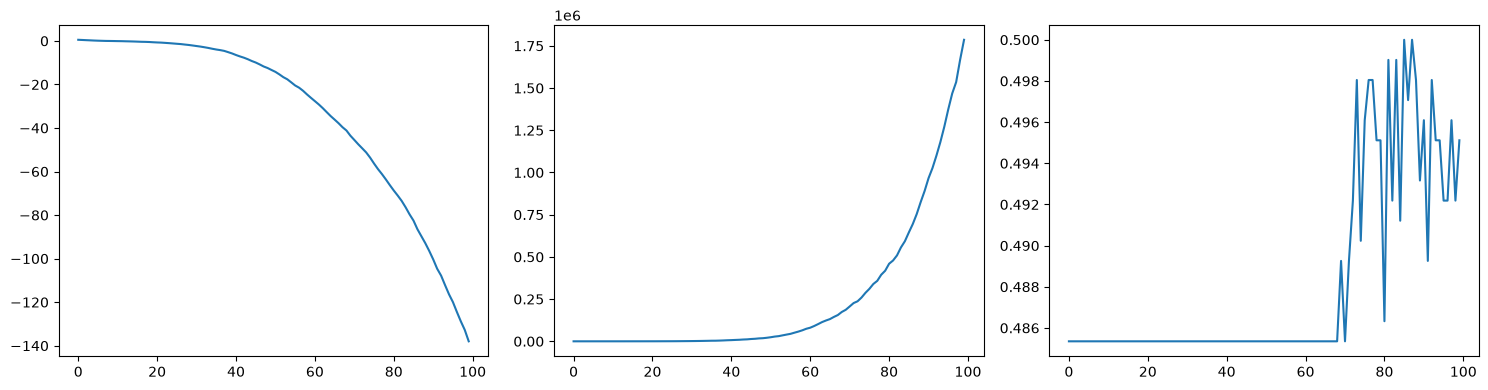

In [6]:

input_dim = 10
hidden_dim = 8

train_samples =  2 ** (input_dim)
eval_samples = train_samples
epochs = 100
batch_size = 256
lr = .01

device = "cpu"

train_x, train_y = generate_parity_data(train_samples, input_dim, device=device)
eval_x, eval_y = generate_parity_data(eval_samples, input_dim, device=device)

#model = ParityMLP(input_dim=input_dim, hidden_dim=hidden_dim)
model = ParityMLP3(input_dim=input_dim, hidden_dim1=hidden_dim, hidden_dim2=100)
sa_arr = []
eval_arr = []
loss_arr = []
model = ParityMLP2(input_dim=input_dim, hidden_dim1=hidden_dim, hidden_dim2 =hidden_dim)
for i in range(epochs):
        
    train_loss = train_model(
        model,
        train_x,
        train_y,
        epochs=1,
        batch_size=batch_size,
        lr=lr,
        device=device
    )
    eval_mse, sign_accuracy = evaluate_model(model, eval_x, eval_y, device=device)
    eval_arr.append(eval_mse)
    sa_arr.append(sign_accuracy)
    loss_arr.append(train_loss)
    
eval_mse, sign_accuracy = evaluate_model(model, eval_x, eval_y, device=device)
print(eval_mse, sign_accuracy )
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.lineplot(loss_arr, ax=axs[0])
sns.lineplot(eval_arr, ax=axs[1])
sns.lineplot(sa_arr, ax=axs[2])
plt.tight_layout()
plt.show()

In [11]:
for name, param in model.named_parameters():
    if 'weight' in name:
        print(f"Layer: {name} | Shape: {param.shape}")
        print(param.data)  # The actual weight tensor


Layer: network.0.weight | Shape: torch.Size([8, 10])
tensor([[-0.1674, -0.1406,  0.3270,  0.0437, -0.1045,  0.1314,  0.1626,  0.3156,
          0.1609, -0.1223],
        [ 0.3956,  0.3956,  0.3956, -0.3956,  0.3955, -0.3956, -0.3956,  0.3956,
          0.3956,  0.3956],
        [-0.3910, -0.3909, -0.3909,  0.3910, -0.3910,  0.3910,  0.3910, -0.3910,
         -0.3910, -0.3910],
        [-0.4250,  0.5884, -0.4262,  0.4220, -0.4256,  0.4262,  0.4254, -0.4256,
         -0.4217, -0.4257],
        [-0.5133, -0.5201, -0.5130,  0.5132, -0.5131,  0.5130,  0.5130, -0.5131,
         -0.5131, -0.5130],
        [ 0.0446,  0.0478, -0.0136, -0.0015, -0.1075, -0.0170,  0.1393,  0.0572,
         -0.1736,  0.1051],
        [ 0.0194, -0.1965, -0.0861, -0.0203, -0.1232,  0.0510,  0.1031, -0.1151,
          0.1178,  0.0075],
        [-0.1891,  0.0135,  0.0031,  0.0921,  0.2268,  0.0321,  0.0705, -0.1462,
          0.0179,  0.0129]])
Layer: network.2.weight | Shape: torch.Size([200, 8])
tensor([[ 0.0237, -0

In [12]:
import torch 
weight_dict = model.state_dict()
h0 = weight_dict["network.0.weight"]
ones = torch.ones(h0.shape[0])
h = torch.column_stack((h0, ones)).double()
h

tensor([[-0.1674, -0.1406,  0.3270,  0.0437, -0.1045,  0.1314,  0.1626,  0.3156,
          0.1609, -0.1223,  1.0000],
        [ 0.3956,  0.3956,  0.3956, -0.3956,  0.3955, -0.3956, -0.3956,  0.3956,
          0.3956,  0.3956,  1.0000],
        [-0.3910, -0.3909, -0.3909,  0.3910, -0.3910,  0.3910,  0.3910, -0.3910,
         -0.3910, -0.3910,  1.0000],
        [-0.4250,  0.5884, -0.4262,  0.4220, -0.4256,  0.4262,  0.4254, -0.4256,
         -0.4217, -0.4257,  1.0000],
        [-0.5133, -0.5201, -0.5130,  0.5132, -0.5131,  0.5130,  0.5130, -0.5131,
         -0.5131, -0.5130,  1.0000],
        [ 0.0446,  0.0478, -0.0136, -0.0015, -0.1075, -0.0170,  0.1393,  0.0572,
         -0.1736,  0.1051,  1.0000],
        [ 0.0194, -0.1965, -0.0861, -0.0203, -0.1232,  0.0510,  0.1031, -0.1151,
          0.1178,  0.0075,  1.0000],
        [-0.1891,  0.0135,  0.0031,  0.0921,  0.2268,  0.0321,  0.0705, -0.1462,
          0.0179,  0.0129,  1.0000]], dtype=torch.float64)

In [13]:
from src import count, gen_hypercubes
import numpy as np
d=10

hpoints1, hpoints2 = gen_hypercubes(d)
edge_set = torch.tensor(np.concatenate((hpoints1, hpoints2)).T).double()

count(d, h, edge_set) / (d*(2**(d-1)))


tensor(0.7625)